In [2]:
# 导入必要库
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [2]:
import cv2
import time

# 打开默认摄像头
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("无法打开摄像头")
    exit()
time.sleep(1)  # 等待1秒，让摄像头适应环境
for i in range(3):
    # 读取摄像头帧
    ret, frame = cap.read()
    if ret:
        # 保存图片，文件名为capture.jpg
        cv2.imwrite(f'capture{i+1}.jpg', frame)
        print(f"已保存为 capture{i+1}.jpg")
    else:
        print("拍照失败")
    
    
    # 等待100毫秒
    if cv2.waitKey(1000) & 0xFF == ord('q'):
        break

# 释放摄像头
cap.release()


已保存为 capture1.jpg
已保存为 capture2.jpg
已保存为 capture3.jpg


In [33]:
# 1. 加载预训练的VGG16模型
model = VGG16(weights='imagenet')
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# 2. 读取并预处理测试图片
img_path = 'capture.jpg'  # 请替换为你的测试图片路径
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
input_img = np.expand_dims(img_array, axis=0)
input_img = preprocess_input(input_img)

In [35]:
# 3. 选择最后一个卷积层作为目标层
last_conv_layer_name = 'block5_conv3'
last_conv_layer = model.get_layer(last_conv_layer_name)

In [36]:
# 4. 创建一个新的模型，输出为目标层的输出和模型最终预测
grad_model = Model(inputs=model.inputs,
                   outputs=[last_conv_layer.output, model.output])

In [37]:

# 5. 计算类别对应的梯度和特征图权重，得到Grad-CAM热力图
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_img)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

# 计算梯度
grads = tape.gradient(class_channel, conv_outputs)

# 计算特征图上的权重（全局平均池化）
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# 加权求和得到热力图
conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

# ReLU激活只保留正值
heatmap = np.maximum(heatmap, 0)

# 归一化热力图到0-1
heatmap /= tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

e:\Application\Anaconda\envs\image2text\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_23']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [38]:
# 6. 将热力图放大到输入图像大小
import cv2
heatmap_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))

In [39]:

# 7. 将热力图叠加到原图上进行可视化展示
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# 原图格式转换（BGR转RGB）
img_rgb = cv2.cvtColor(img_array.astype('uint8'), cv2.COLOR_RGB2BGR)

superimposed_img = heatmap_colored * 0.4 + img_rgb

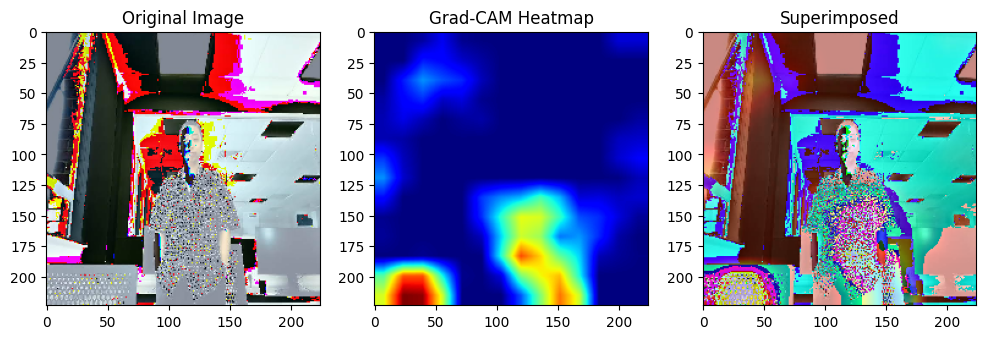

Predicted: ('n03000247', 'chain_mail', 0.29885194)


In [40]:
# 8. 显示结果
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title('Original Image')
plt.imshow(img_array.astype('uint8'))

plt.subplot(1,3,2)
plt.title('Grad-CAM Heatmap')
plt.imshow(heatmap_resized, cmap='jet')

plt.subplot(1,3,3)
plt.title('Superimposed')
plt.imshow(superimposed_img.astype('uint8'))
plt.show()

# 9. 打印预测类别
print('Predicted:', decode_predictions(predictions.numpy())[0][0])